# Работа 3: Классификация с помощью дерева решений

## 1. Формулировка задания
1. Разработать программу классификации данных с помощью дерева решений.
   - Критерий выбора атрибута разбиения: **Information Gain**, **Gain Ratio**, **Gini Index**;
   - Доля обучающей выборки (`train_ratio`).
2. Провести эксперименты на наборе данных **Census Income (Adult Dataset)**:
   - Построить деревья решений при использовании 100% обучающей выборки и визуализировать их структуру.
   - Варьировать соотношение мощностей обучающей и тестовой выборок от 60%:40% до 90%:10% с шагом 10% для каждого критерия.
   - Вычислять показатели качества классификации: **Accuracy**, **Precision**, **Recall**, **F1-score**.
3. Выполнить визуализацию полученных результатов:
   - Структура построенных деревьев решений;
   - Графики зависимости метрик качества от доли обучающей выборки для каждого критерия.
4. Проанализировать полученные результаты.

## 2. Ссылка на репозиторий
Каталог репозиторий: `https://github.com/GeRoNioPLAY/Data_analysis`

In [61]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

np.random.seed(42)

## 3. Загрузка и предварительная обработка данных

In [62]:
COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",
]

NUMERIC_COLS = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]
CATEGORICAL_COLS = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

TRAIN_FILE = "adult.data"
TEST_FILE = "adult.test"


def load_clean_data(train_path, test_path):
    df_train = pd.read_csv(
        train_path,
        names=COLUMNS,
        sep=r"\s*,\s*",
        engine="python",
        na_values="?",
        comment="|",
    )
    df_test = pd.read_csv(
        test_path,
        names=COLUMNS,
        sep=r"\s*,\s*",
        engine="python",
        na_values="?",
        comment="|",
    )

    df = pd.concat([df_train, df_test], ignore_index=True)

    df["income"] = (
        df["income"].astype(str).str.strip().str.replace(".", "", regex=False)
    )
    df = df[df["income"].isin(["<=50K", ">50K"])].copy()
    df.dropna(inplace=True)
    df["income"] = (df["income"] == ">50K").astype(np.int32)
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)
    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype(str).str.strip()

    return df


df_full = load_clean_data(TRAIN_FILE, TEST_FILE)
print(f"Успешно обработано строк: {len(df_full)}")
print("Типы столбцов:")
print(df_full.dtypes)

Успешно обработано строк: 45222
Типы столбцов:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income            int32
dtype: object


## 4. Реализация дерева решений
Реализован класс `DecisionTreeCustom`, поддерживающий три критерия разбиения:
- **Information Gain**
- **Gain Ratio**
- **Gini Index**

In [63]:
class Node:
    def __init__(
        self,
        feature=None,
        threshold=None,
        is_categorical=False,
        left=None,
        right=None,
        *,
        value=None,
    ):
        self.feature = feature
        self.threshold = threshold
        self.is_categorical = is_categorical
        self.left = left
        self.right = right
        self.value = value

    @property
    def is_leaf(self):
        return self.value is not None


class DecisionTreeCustom:
    def __init__(
        self,
        criterion="information_gain",
        max_depth=4,
        min_samples_split=30,
        n_quantiles=10,
    ):
        self.criterion = criterion.lower()
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_quantiles = n_quantiles
        self.root = None

    def _entropy(self, y):
        n = len(y)
        if n == 0:
            return 0.0
        p = float(np.mean(y))
        if p <= 0.0 or p >= 1.0:
            return 0.0
        return -p * math.log2(p) - (1.0 - p) * math.log2(1.0 - p)

    def _gini(self, y):
        n = len(y)
        if n == 0:
            return 0.0
        p = float(np.mean(y))
        return 2.0 * p * (1.0 - p)

    def _split_info(self, n_total, n_l, n_r):
        p_l = n_l / n_total
        p_r = n_r / n_total
        s_info = 0.0
        if p_l > 0.0:
            s_info -= p_l * math.log2(p_l)
        if p_r > 0.0:
            s_info -= p_r * math.log2(p_r)
        return s_info

    def _calc_metric(self, y_parent, y_l, y_r):
        n = len(y_parent)
        n_l, n_r = len(y_l), len(y_r)
        if n_l == 0 or n_r == 0:
            return -1.0

        if self.criterion == "information_gain":
            parent_ent = self._entropy(y_parent)
            weighted_ent = (n_l / n) * self._entropy(y_l) + (n_r / n) * self._entropy(
                y_r
            )
            return parent_ent - weighted_ent

        elif self.criterion == "gain_ratio":
            parent_ent = self._entropy(y_parent)
            weighted_ent = (n_l / n) * self._entropy(y_l) + (n_r / n) * self._entropy(
                y_r
            )
            ig = parent_ent - weighted_ent
            si = self._split_info(n, n_l, n_r)
            return (ig / (si + 1e-9)) if si > 0 else 0.0

        elif self.criterion == "gini":
            parent_gini = self._gini(y_parent)
            weighted_gini = (n_l / n) * self._gini(y_l) + (n_r / n) * self._gini(y_r)
            return parent_gini - weighted_gini

        else:
            raise ValueError(f"Неизвестный критерий: {self.criterion}")

    def _get_splits(self, X_col, is_cat):
        if is_cat:
            return np.unique(X_col)
        else:
            q = np.linspace(0.05, 0.95, self.n_quantiles)
            return np.unique(np.quantile(X_col, q))

    def _best_split(self, X, y):
        best_score = -1.0
        split_feat, split_thresh, split_cat = None, None, False

        for col in X.columns:
            col_vals = X[col].values
            is_cat = col in CATEGORICAL_COLS or col_vals.dtype == "object"
            thresholds = self._get_splits(col_vals, is_cat)

            for val in thresholds:
                if is_cat:
                    mask_l = col_vals == val
                else:
                    mask_l = col_vals <= val

                y_l, y_r = y[mask_l], y[~mask_l]
                score = self._calc_metric(y, y_l, y_r)

                if score > best_score:
                    best_score = score
                    split_feat = col
                    split_thresh = val
                    split_cat = is_cat

        return split_feat, split_thresh, split_cat, best_score

    def _build_tree(self, X, y, depth=0):
        if (
            len(np.unique(y)) <= 1
            or depth >= self.max_depth
            or len(y) < self.min_samples_split
        ):
            leaf_val = 1 if np.mean(y) >= 0.5 else 0
            return Node(value=leaf_val)

        feat, thresh, is_cat, score = self._best_split(X, y)

        if feat is None or score <= 1e-7:
            leaf_val = 1 if np.mean(y) >= 0.5 else 0
            return Node(value=leaf_val)

        if is_cat:
            mask_l = (X[feat] == thresh).values
        else:
            mask_l = (X[feat] <= thresh).values

        left = self._build_tree(X.iloc[mask_l], y[mask_l], depth + 1)
        right = self._build_tree(X.iloc[~mask_l], y[~mask_l], depth + 1)

        return Node(
            feature=feat,
            threshold=thresh,
            is_categorical=is_cat,
            left=left,
            right=right,
        )

    def fit(self, X, y):
        y_arr = np.asarray(y, dtype=np.float64)
        self.root = self._build_tree(X.reset_index(drop=True), y_arr)
        return self

    def _predict_sample(self, node, x):
        if node.is_leaf:
            return node.value
        val = x[node.feature]
        if node.is_categorical:
            cond = val == node.threshold
        else:
            cond = float(val) <= float(node.threshold)
        return (
            self._predict_sample(node.left, x)
            if cond
            else self._predict_sample(node.right, x)
        )

    def predict(self, X):
        return np.array(
            [self._predict_sample(self.root, row) for _, row in X.iterrows()]
        )

## 5. Эксперимент 1: Обучение деревьев на 100% данных и их визуализация
Обучим дерево решений для каждого из трех критериев при обучении на полном датасете и отобразим структуру деревьев в текстовом и псевдографическом виде.

In [64]:
def print_tree(node, depth=0, prefix="Root: "):
    indent = "    " * depth
    if node.is_leaf:
        print(f"{indent}{prefix}--> Прогноз: {'>50K' if node.value == 1 else '<=50K'}")
        return

    op = "==" if node.is_categorical else "<="
    thresh = f"'{node.threshold}'" if node.is_categorical else f"{node.threshold:.2f}"
    print(f"{indent}{prefix}[{node.feature} {op} {thresh}]")
    print_tree(node.left, depth + 1, prefix="Да: ")
    print_tree(node.right, depth + 1, prefix="Нет: ")


X_full = df_full.drop("income", axis=1)
y_full = df_full["income"]

criteria = ["information_gain", "gain_ratio", "gini"]
fitted_trees = {}

for crit in criteria:
    print("=" * 80)
    print(f"ПОСТРОЕНИЕ ДЕРЕВА РЕШЕНИЙ (100% данных) | Критерий: {crit.upper()}")
    print("=" * 80)
    dt = DecisionTreeCustom(criterion=crit, max_depth=3, min_samples_split=50)
    dt.fit(X_full, y_full)
    fitted_trees[crit] = dt
    print_tree(dt.root)
    print("\n")

ПОСТРОЕНИЕ ДЕРЕВА РЕШЕНИЙ (100% данных) | Критерий: INFORMATION_GAIN
Root: [marital-status == 'Married-civ-spouse']
    Да: [education-num <= 11.00]
        Да: [capital-gain <= 5013.00]
            Да: --> Прогноз: <=50K
            Нет: --> Прогноз: >50K
        Нет: [capital-gain <= 4386.00]
            Да: --> Прогноз: >50K
            Нет: --> Прогноз: >50K
    Нет: [education-num <= 11.00]
        Да: [capital-gain <= 0.00]
            Да: --> Прогноз: <=50K
            Нет: --> Прогноз: <=50K
        Нет: [capital-gain <= 6849.00]
            Да: --> Прогноз: <=50K
            Нет: --> Прогноз: >50K


ПОСТРОЕНИЕ ДЕРЕВА РЕШЕНИЙ (100% данных) | Критерий: GAIN_RATIO
Root: [capital-gain <= 5013.00]
    Да: [marital-status == 'Married-civ-spouse']
        Да: [education-num <= 11.00]
            Да: --> Прогноз: <=50K
            Нет: --> Прогноз: >50K
        Нет: [education-num <= 14.00]
            Да: --> Прогноз: <=50K
            Нет: --> Прогноз: <=50K
    Нет: [relationship =

## 6. Эксперимент 2: Исследование зависимости метрик качества от доли обучающей выборки
Варьируем долю обучающей выборки от **60% до 90% с шагом 10%** (тестовая выборка соответственно от 40% до 10%).  
Для каждого критерия вычисляются:
- **Accuracy** (аккуратность)
- **Precision** (точность)
- **Recall** (полнота)
- **F-мера (F1-score)**

In [65]:
train_ratios = [0.60, 0.70, 0.80, 0.90]

results = []

sample_size = 8000
df_sub = df_full.sample(n=sample_size, random_state=42).reset_index(drop=True)
X_sub = df_sub.drop("income", axis=1)
y_sub = df_sub["income"]

for crit in criteria:
    for tr in train_ratios:
        split_idx = int(len(df_sub) * tr)
        perm = np.random.permutation(len(df_sub))
        train_idx, test_idx = perm[:split_idx], perm[split_idx:]

        X_train, y_train = X_sub.iloc[train_idx], y_sub.iloc[train_idx]
        X_test, y_test = X_sub.iloc[test_idx], y_sub.iloc[test_idx]

        model = DecisionTreeCustom(criterion=crit, max_depth=4, min_samples_split=20)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        results.append(
            {
                "Критерий": crit,
                "Train Ratio": f"{int(tr * 100)}% / {int((1 - tr) * 100)}%",
                "Train Proportion": tr,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1,
            }
        )

df_results = pd.DataFrame(results)
df_results

,Критерий,Train Ratio,Train Proportion,Accuracy,Precision,Recall,F1-Score
0,information_gain,60% / 40%,0.6,0.823125,0.748718,0.511085,0.607490
1,information_gain,70% / 30%,0.7,0.828750,0.751244,0.492659,0.595074
2,information_gain,80% / 19%,0.8,0.838750,0.756014,0.540541,0.630372
3,information_gain,90% / 9%,0.9,0.831250,0.712329,0.527919,0.606414
4,gain_ratio,60% / 40%,0.6,0.790000,0.896373,0.209697,0.339882
5,gain_ratio,70% / 30%,0.7,0.792917,0.965517,0.185124,0.310680
6,gain_ratio,80% / 19%,0.8,0.791875,0.965116,0.200969,0.332665
7,gain_ratio,90% / 9%,0.9,0.766250,0.911111,0.183036,0.304833
8,gini,60% / 40%,0.6,0.847187,0.764602,0.548223,0.638581
9,gini,70% / 30%,0.7,0.830000,0.753695,0.498371,0.600000


## 7. Визуализация показателей качества классификации
Построение сравнительных графиков динамики метрик качества (Accuracy, Precision, Recall, F1) в зависимости от соотношения обучающей и тестовой выборок.

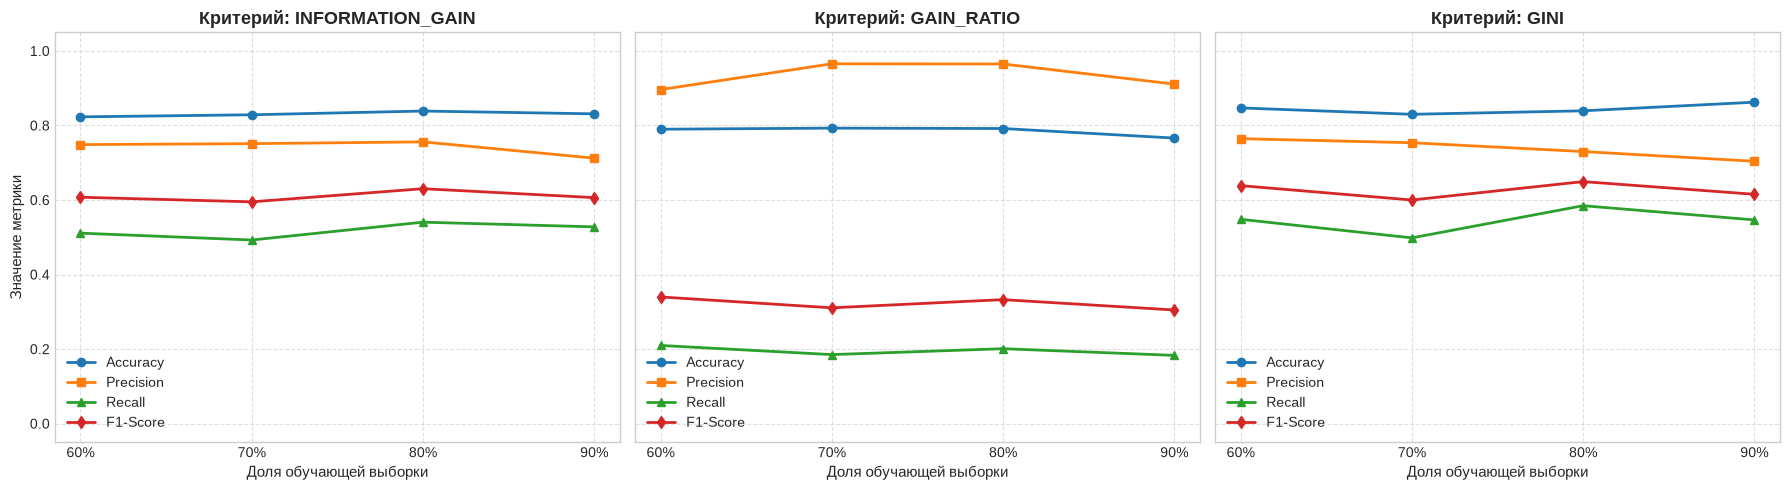

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, crit in enumerate(criteria):
    df_c = df_results[df_results["Критерий"] == crit]
    x_axis = [f"{int(tr * 100)}%" for tr in df_c["Train Proportion"]]

    axes[i].plot(x_axis, df_c["Accuracy"], marker="o", label="Accuracy", linewidth=2)
    axes[i].plot(x_axis, df_c["Precision"], marker="s", label="Precision", linewidth=2)
    axes[i].plot(x_axis, df_c["Recall"], marker="^", label="Recall", linewidth=2)
    axes[i].plot(x_axis, df_c["F1-Score"], marker="d", label="F1-Score", linewidth=2)

    axes[i].set_title(f"Критерий: {crit.upper()}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Доля обучающей выборки", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Значение метрики", fontsize=11)

    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(loc="lower left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 8. Пояснения и выводы

### Краткий вывод

1. **Ключевые факторы:** во всех моделях решающими признаками стали семейный статус (`marital-status`), уровень образования (`education-num`) и прирост капитала (`capital-gain`).
2. **Сравнение критериев:** **Gini Index** и **Information Gain** показали лучший баланс качества (Accuracy $\approx 83\text{–}86\%$, F1-Score $\approx 0.60\text{–}0.65$), в то время как **Gain Ratio** ушёл в консервативную стратегию с экстремально высокой точностью (Precision до $96.5\%$), но низкой полнотой (Recall $\approx 18\text{–}21\%$).
3. **Влияние размера выборки:** изменение доли обучающих данных с 60% до 90% не оказывает сильного влияния на метрики — дерев
о быстро находит ключевые правила даже на меньшей выборке, а наилучший общий результат показал **Gini Index** при 80–90% train.